# Exploratory Data Analysis — Bagmati Forest-Fire Dataset

In [1]:
import warnings
import os
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 130})

ROOT =Path(os.getcwd()).parent
EDA  = ROOT/"outputs" / "figures" / "eda"; EDA.mkdir(parents=True, exist_ok=True)


df_all = pd.read_parquet(ROOT / "data/processed/forest_fire_dataset_100m.parquet")
print("full grid:", df_all.shape, f"| memory {df_all.memory_usage(deep=True).sum()/1e6:.0f} MB")

# only flammable cells
df = df_all[df_all.is_flammable == 1].reset_index(drop=True)   # modelling universe
print("flammable:", df.shape, f"| fire rate {df.fire_occurred.mean():.3%}")


df_all.dtypes.to_frame("dtype").join(df_all.notna().mean().to_frame("non_null")).head(45)

full grid: (2652763, 42) | memory 467 MB
flammable: (2123648, 42) | fire rate 0.195%


,dtype,non_null
lat,float64,1.000000
lon,float64,1.000000
lulc_code,float32,1.000000
is_flammable,float32,1.000000
elevation_m,float32,1.000000
slope_deg,float32,1.000000
aspect_deg,float32,1.000000
tri,float32,0.999849
twi,float32,1.000000
solar_radiation,float32,1.000000


## Target — fire occurrence & counts


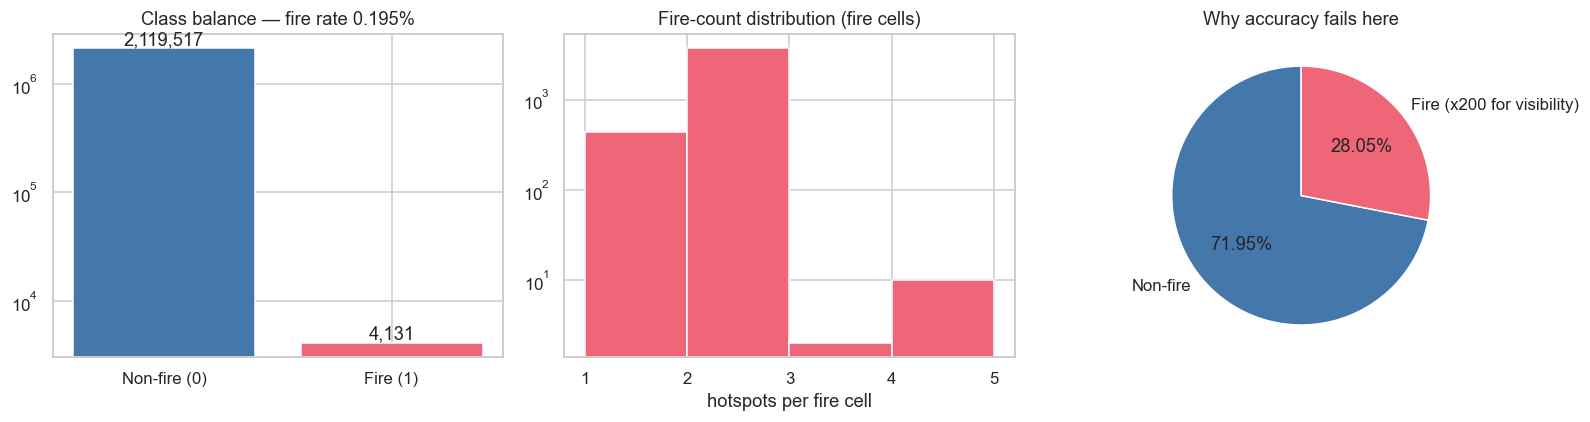

non-fire 2,119,517 | fire 4,131 | ratio 1:513


In [2]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
vc = df.fire_occurred.value_counts().sort_index()


ax[0].bar(["Non-fire (0)","Fire (1)"], vc.values, color=["#4477AA","#EE6677"])
ax[0].set_yscale("log")
ax[0].set_title(f"Class balance — fire rate {df.fire_occurred.mean():.3%}")

for i,v in enumerate(vc.values): 
    ax[0].text(i, v, f"{v:,}", ha="center", va="bottom")

fc = df[df.fire_count > 0].fire_count
ax[1].hist(fc, bins=range(1, int(fc.max())+2), color="#EE6677", edgecolor="white")
ax[1].set_yscale("log")
ax[1].set_xlabel("hotspots per fire cell")
ax[1].set_title("Fire-count distribution (fire cells)")

ax[2].pie([vc.values[0], vc.values[1]*200], labels=["Non-fire","Fire (x200 for visibility)"],
          colors=["#4477AA","#EE6677"], autopct="%1.2f%%", startangle=90)
ax[2].set_title("Why accuracy fails here")
plt.tight_layout(); plt.savefig(EDA/"target_overview.png")
plt.show()
print(f"non-fire {vc.values[0]:,} | fire {vc.values[1]:,} | ratio 1:{vc.values[0]//vc.values[1]}")

**Analysis**<br>

This is a severe class imbalance problem. Models **must use metrics like F1, AUC-PR, or recall rather than accuracy.**

## Land cover & flammability

Land Use/ Land Cover Counts lulc_code
Tree cover     1744875
Grassland       376589
Cropland        227097
Snow/Ice         94537
Bare/Sparse      89262
Moss/Lichen      68507
Built-up         38344
Water            11325
Shrubland         2184
Wetland             43
Name: count, dtype: int64
Flammable Land Use/ Land Cover Counts lulc_code
Tree cover    1744875
Grassland      376589
Shrubland        2184
Name: count, dtype: int64
Fire Rate by Land-Cover Class lulc_code
Grassland     0.001370
Tree cover    0.002065
Shrubland     0.005495
Name: fire_occurred, dtype: float32
Land Cover and Flammability


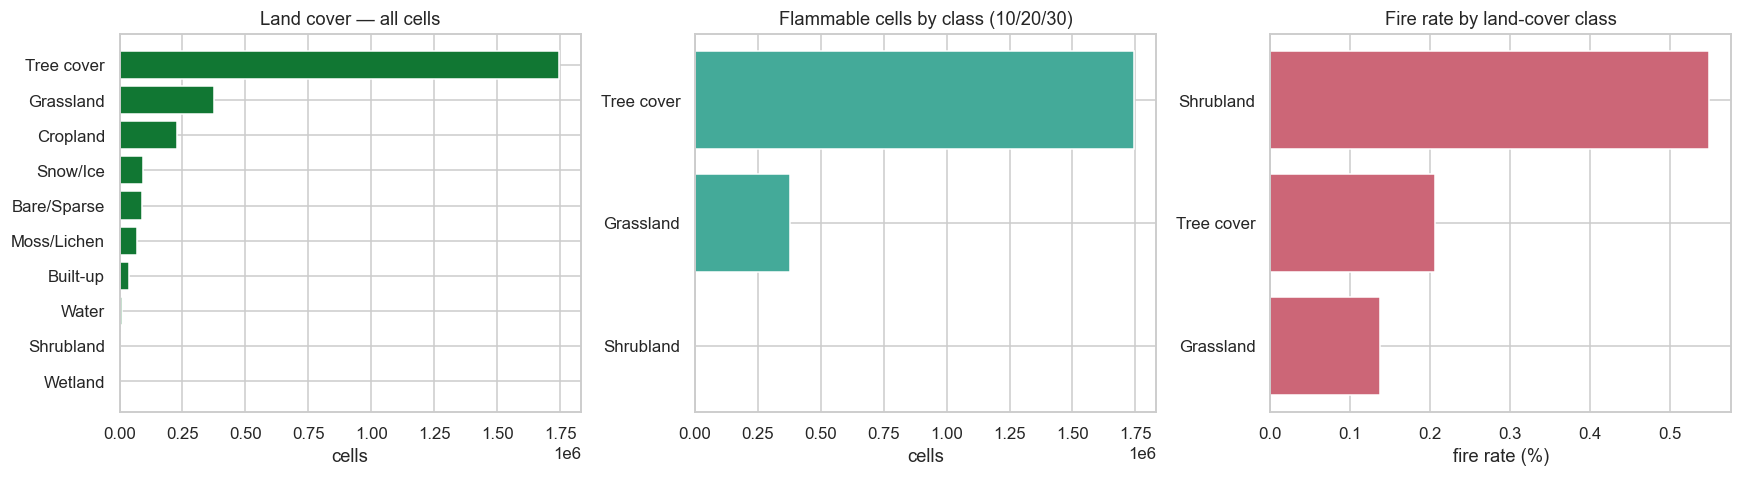

In [3]:
LULC = {
        10:"Tree cover",
        20:"Shrubland",
        30:"Grassland",
        40:"Cropland",
        50:"Built-up",
        60:"Bare/Sparse",
        70:"Snow/Ice",
        80:"Water",
        90:"Wetland",
        95:"Mangrove",
        100:"Moss/Lichen"
        }
fig, ax = plt.subplots(1, 3, figsize=(16, 4.5))


cnt = df_all.lulc_code.map(LULC).value_counts()
print("Land Use/ Land Cover Counts", cnt)
ax[0].barh(cnt.index[::-1], cnt.values[::-1], color="#117733")
ax[0].set_title("Land cover — all cells")
ax[0].set_xlabel("cells")


fcnt = df.lulc_code.map(LULC).value_counts()
print("==========================\nFlammable Land Use/ Land Cover Counts", fcnt)
ax[1].barh(fcnt.index[::-1], fcnt.values[::-1], color="#44AA99")
ax[1].set_title("Flammable cells by class (10/20/30)")
ax[1].set_xlabel("cells")


fr = df.groupby(df.lulc_code.map(LULC)).fire_occurred.mean().sort_values()
print("==========================\nFire Rate by Land-Cover Class", fr)
ax[2].barh(fr.index, fr.values*100, color="#CC6677")
ax[2].set_title("Fire rate by land-cover class")
ax[2].set_xlabel("fire rate (%)")
plt.tight_layout()

print("Land Cover and Flammability")
plt.savefig(EDA/"landcover.png")

plt.show()

**Analysis**: <br>

Land cover is both a filter (defines flammability) and a predictor (fire likelihood differs across flammable classes).

##  Raster maps of the province


Raster Map of the Province: Latitude and Longitude 84.0 and 28.4 with resolution 0.0008333333333333334 (3 arc-second cells)


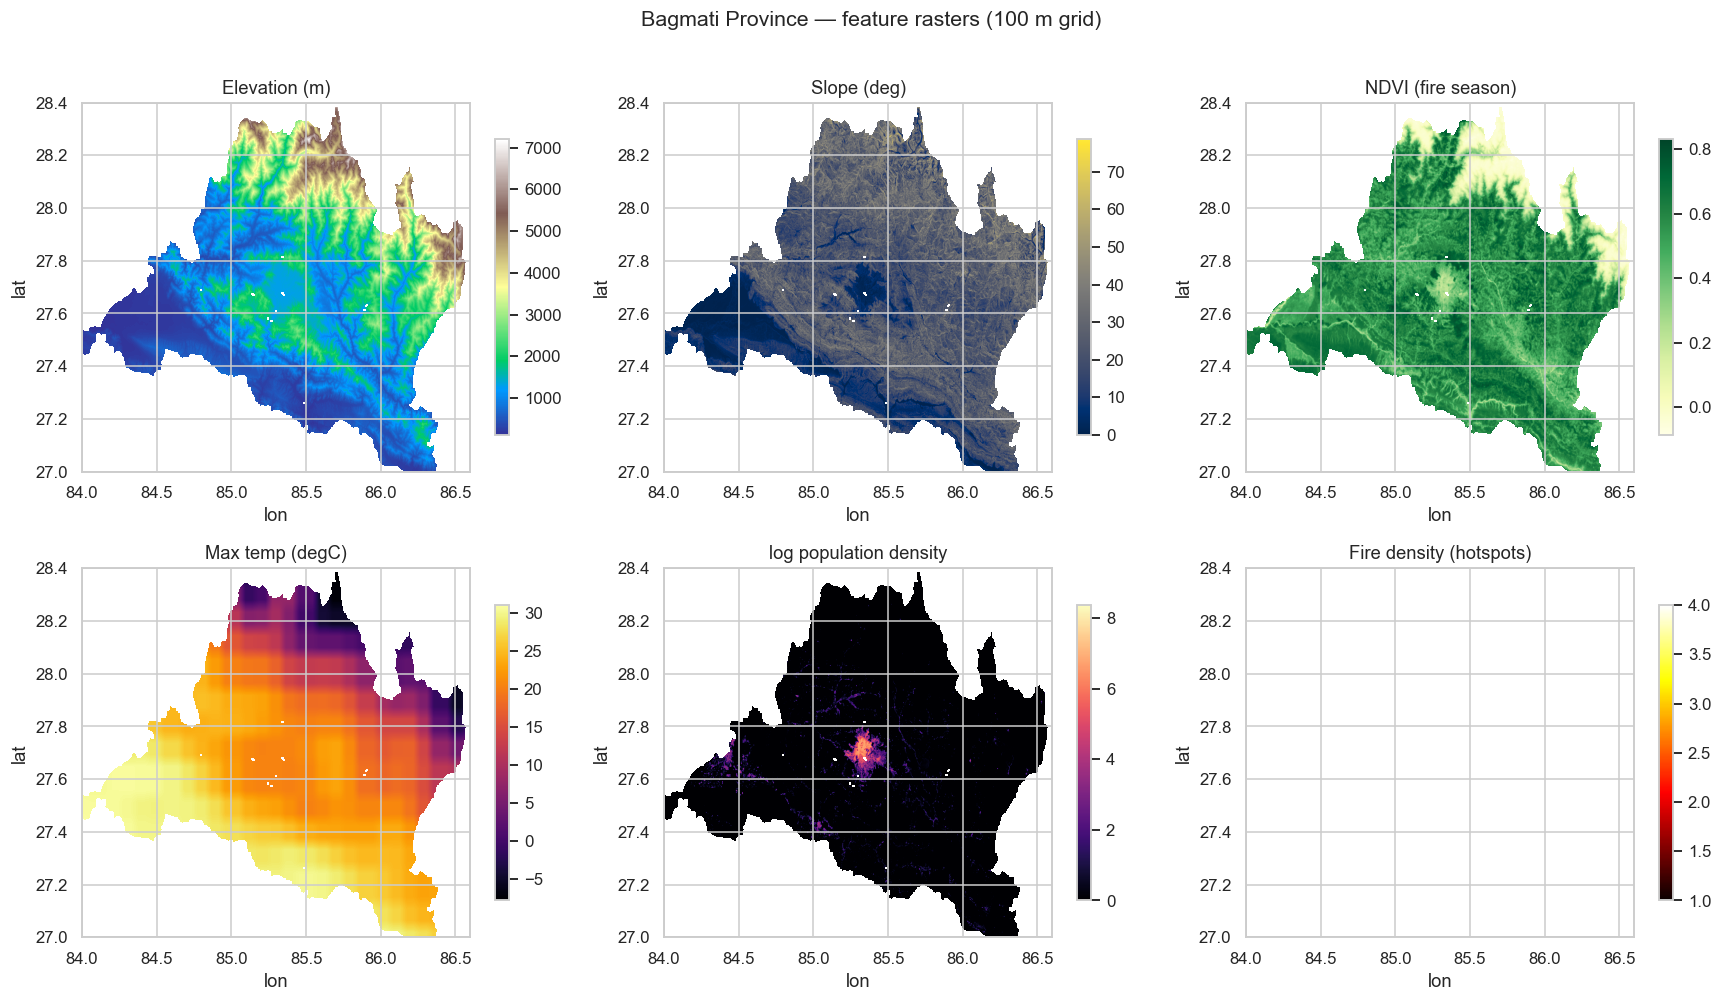

In [4]:
LON0, LAT1, RES = 84.0, 28.4, 3.0/3600.0
W = int(round((86.6-84.0)/RES))
H = int(round((28.4-27.0)/RES))

col = np.clip(((df_all.lon.values-LON0)/RES).astype(int), 0, W-1)
row = np.clip(((LAT1-df_all.lat.values)/RES).astype(int), 0, H-1)

print(f"Raster Map of the Province: Latitude and Longitude {LON0} and {LAT1} with resolution {RES} (3 arc-second cells)")

def raster(series):
    g = np.full((H, W), np.nan, dtype="float32")
    g[row, col] = series.values
    return g

panels = [
    ("elevation_m","terrain","Elevation (m)"),
    ("slope_deg","cividis","Slope (deg)"),
    ("ndvi_fire_season","YlGn","NDVI (fire season)"),
    ("temp_max_mean_c","inferno","Max temp (degC)"),
    ("log_population_density","magma","log population density"),
    ("fire_count","hot","Fire density (hotspots)")
    ]
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.ravel()
for ax, (c, cm, t) in zip(axes, panels):
    g = raster(df_all[c]) if c != "fire_count" else raster(df_all[c].where(df_all[c] > 0))
    im = ax.imshow(g, cmap=cm, extent=[84.0,86.6,27.0,28.4], origin="upper", aspect="auto")
    fig.colorbar(im, ax=ax, shrink=0.8)
    ax.set_title(t)
    ax.set_xlabel("lon")
    ax.set_ylabel("lat")
fig.suptitle("Bagmati Province — feature rasters (100 m grid)", y=1.01, fontsize=14)
plt.tight_layout()
plt.savefig(EDA/"rasters.png", bbox_inches="tight")
plt.show()

**Analysis**<br>

Fire occurrence has a clear spatial structure — mid-elevation transitional zones with dry vegetation and human access are the hotspots.

##  Feature distributions (histograms)

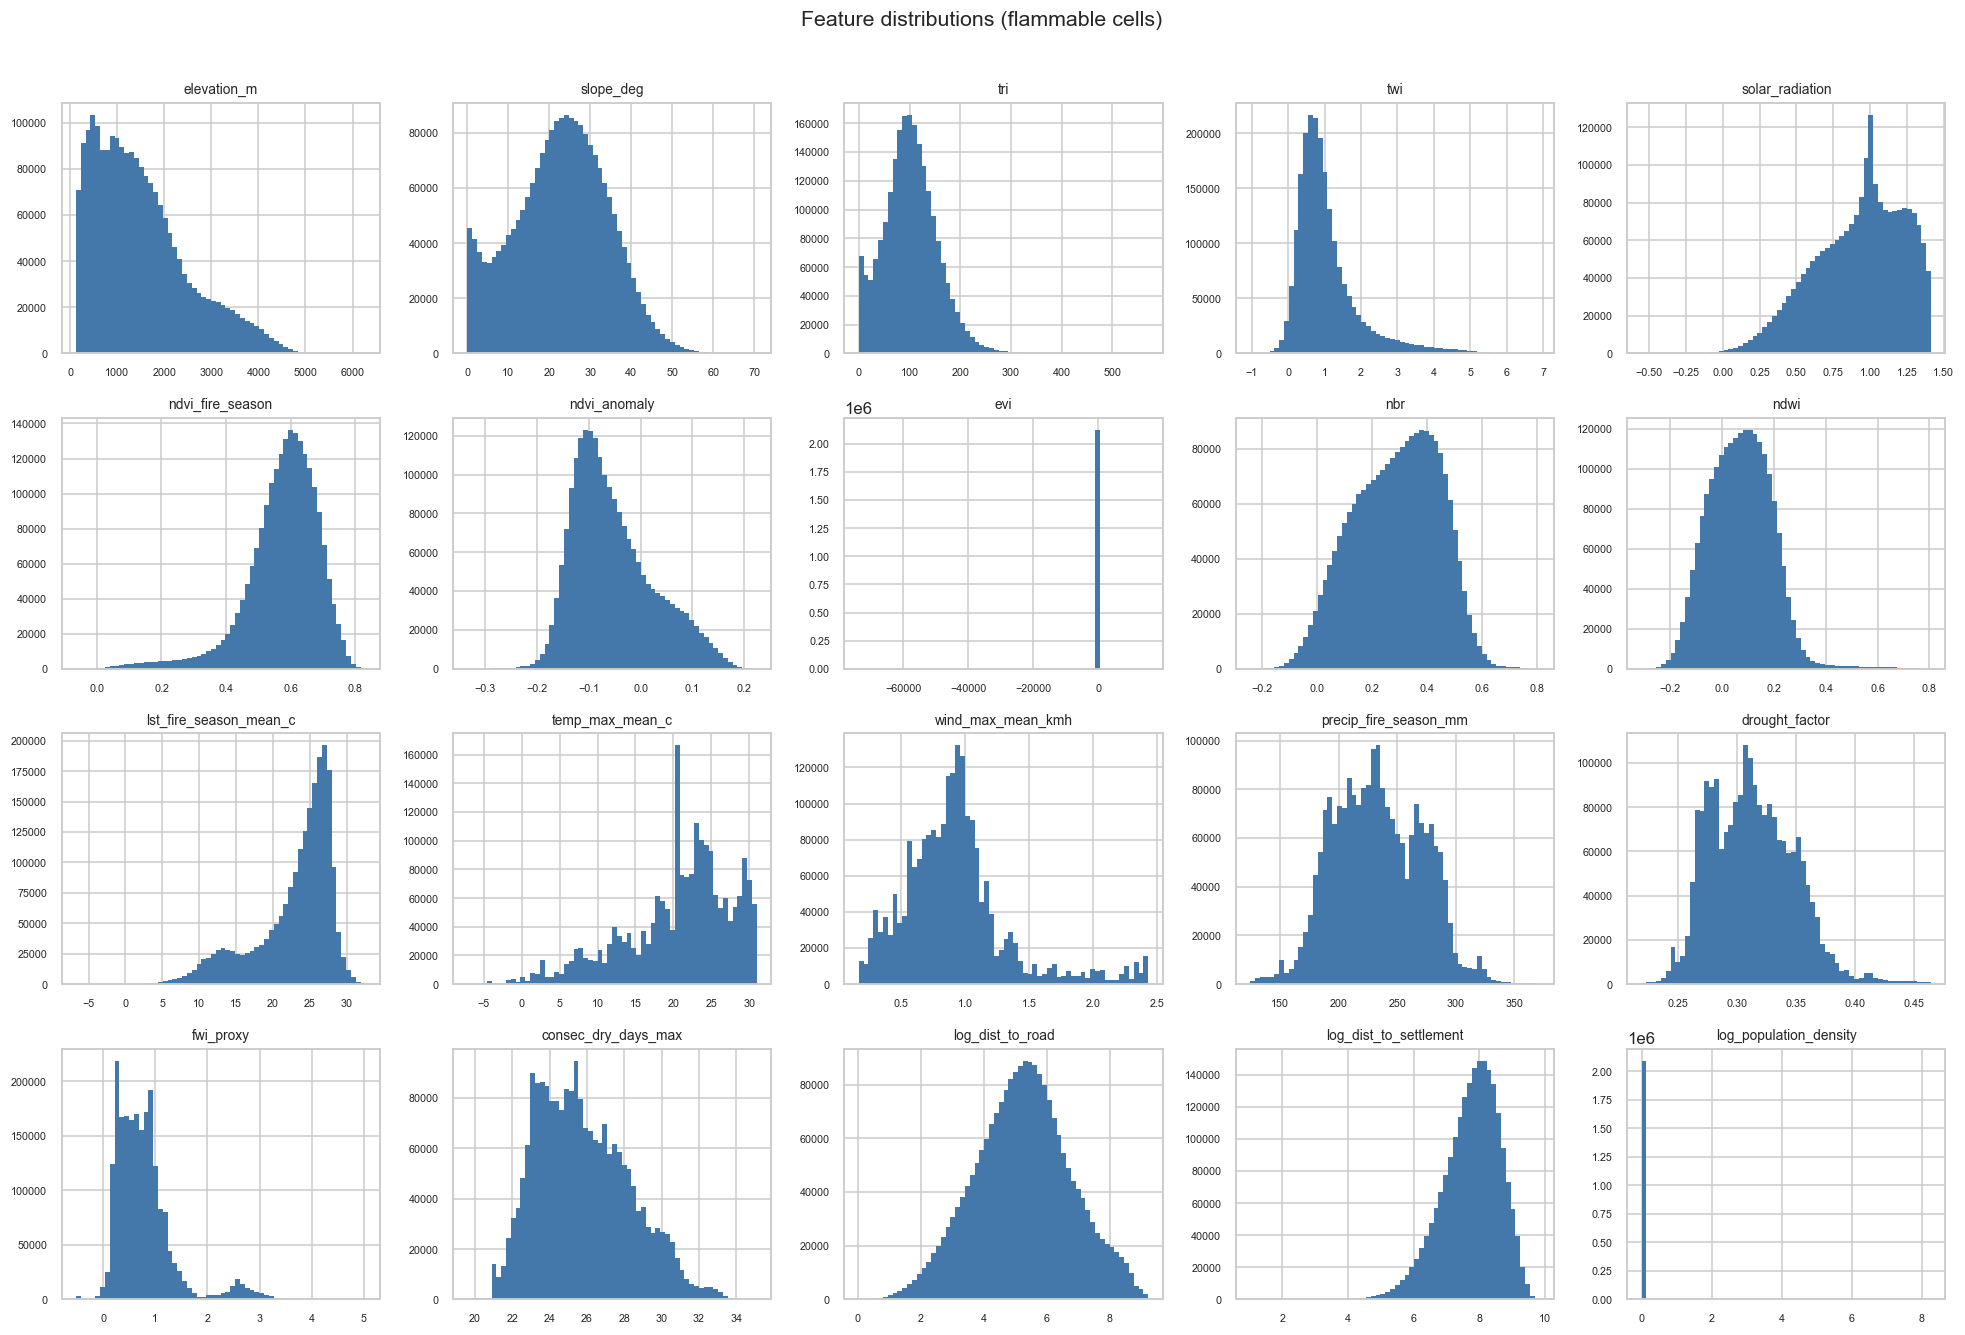

In [5]:
HIST = [
    "elevation_m",
    "slope_deg",
    "tri",
    "twi",
    "solar_radiation",
    "ndvi_fire_season",
    "ndvi_anomaly",
    "evi",
    "nbr",
    "ndwi",
    "lst_fire_season_mean_c",
    "temp_max_mean_c",
    "wind_max_mean_kmh",
    "precip_fire_season_mm",
    "drought_factor",
    "fwi_proxy",
    "consec_dry_days_max",
    "log_dist_to_road",
    "log_dist_to_settlement",
    "log_population_density"
    ]
fig, axes = plt.subplots(4, 5, figsize=(18, 12)); axes = axes.ravel()
for ax, c in zip(axes, HIST):
    ax.hist(df[c].dropna(), bins=60, color="#4477AA", edgecolor="none")
    ax.set_title(c, fontsize=9)
    ax.tick_params(labelsize=7)
fig.suptitle("Feature distributions (flammable cells)", y=1.01, fontsize=14)
plt.tight_layout()
plt.savefig(EDA/"histograms.png", bbox_inches="tight")
plt.show()

**Analysis** <br>

The log-transformations on distance and population variables are well-justified — they normalize heavy right skews common in spatial proximity data.

## Correlation heatmap


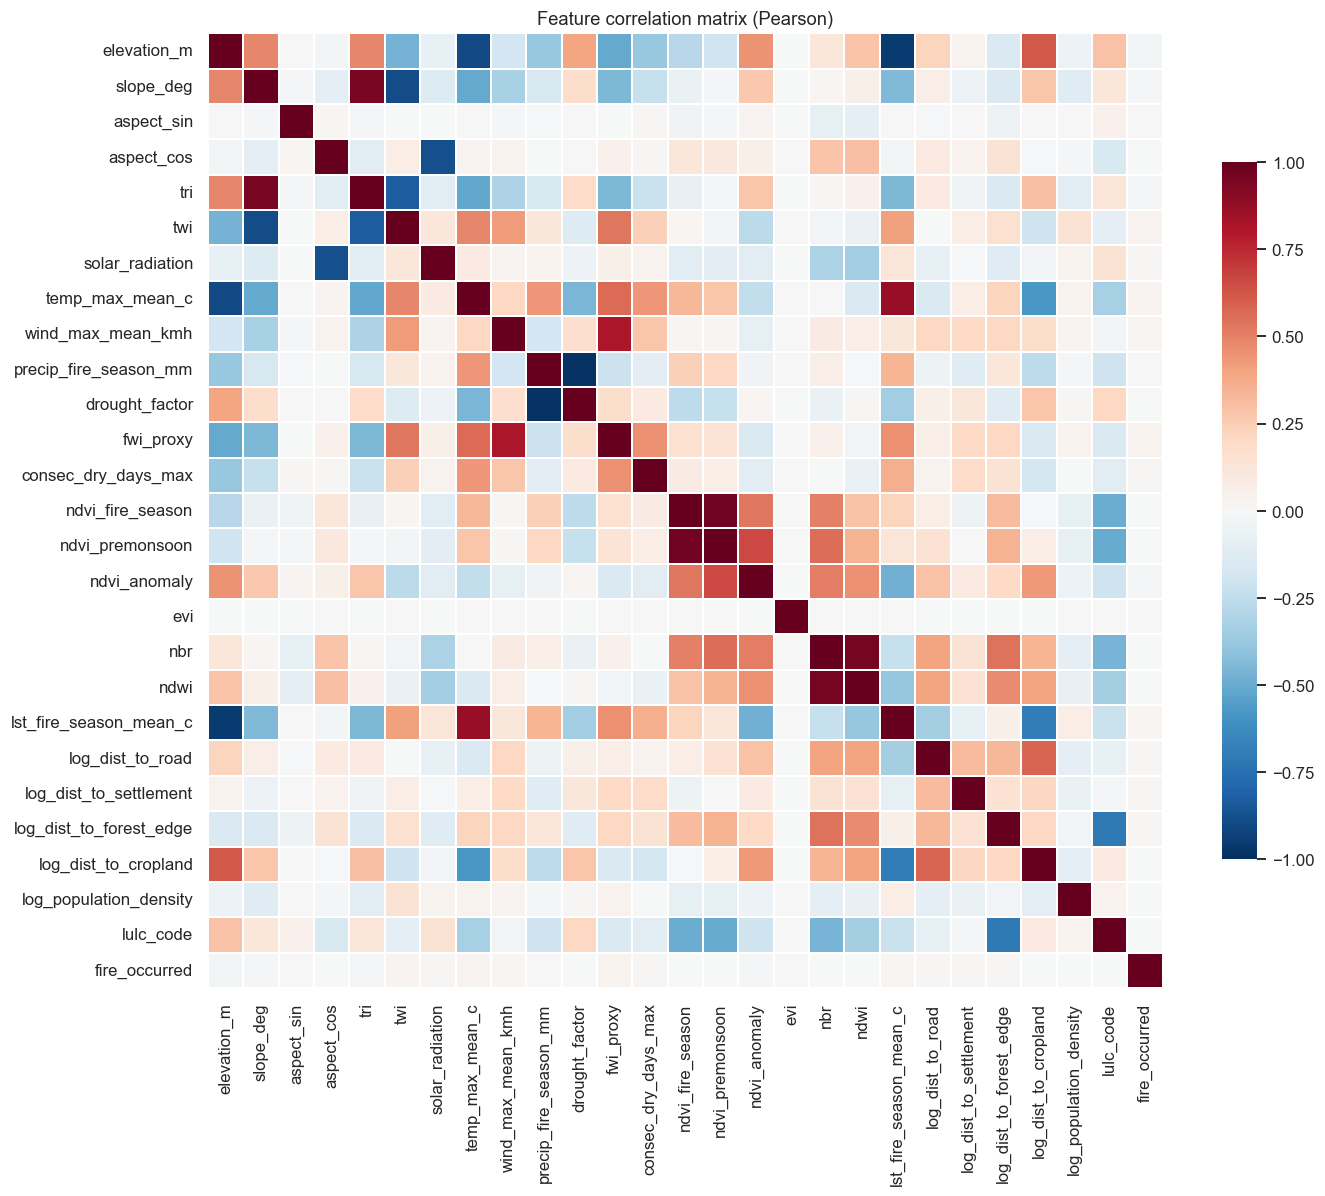

Top correlations with fire_occurred:
fwi_proxy                 0.033
twi                       0.031
elevation_m               0.027
temp_max_mean_c           0.025
lst_fire_season_mean_c    0.023
wind_max_mean_kmh         0.022
ndvi_anomaly              0.021
slope_deg                 0.020
tri                       0.019
consec_dry_days_max       0.013
Name: fire_occurred, dtype: float64


In [6]:
FEAT = [
        "elevation_m",
        "slope_deg",
        "aspect_sin",
        "aspect_cos",
        "tri",
        "twi",
        "solar_radiation",
        "temp_max_mean_c",
        "wind_max_mean_kmh",
        "precip_fire_season_mm",
        "drought_factor",
        "fwi_proxy",
        "consec_dry_days_max",
        "ndvi_fire_season",
        "ndvi_premonsoon",
        "ndvi_anomaly",
        "evi",
        "nbr",
        "ndwi",
        "lst_fire_season_mean_c",
        "log_dist_to_road",
        "log_dist_to_settlement",
        "log_dist_to_forest_edge",
        "log_dist_to_cropland",
        "log_population_density",
        "lulc_code",
        "fire_occurred"
        ]
corr = df[FEAT].corr()
fig, ax = plt.subplots(figsize=(13, 11))
sns.heatmap(corr, cmap="RdBu_r", center=0, vmin=-1, vmax=1, square=True,
            linewidths=0.3, cbar_kws={"shrink":0.7}, ax=ax)
ax.set_title("Feature correlation matrix (Pearson)")
plt.tight_layout()
plt.savefig(EDA/"correlation.png", bbox_inches="tight")
plt.show()

print("Top correlations with fire_occurred:")
print(corr["fire_occurred"].drop("fire_occurred").abs().sort_values(ascending=False).head(10).round(3))

**Analysis** <br>

Multicollinearity exists (e.g., temperature indices, vegetation indices). Tree-based models handle this naturally; linear models may need VIF analysis.

##  Fire vs non-fire separation (box plots)

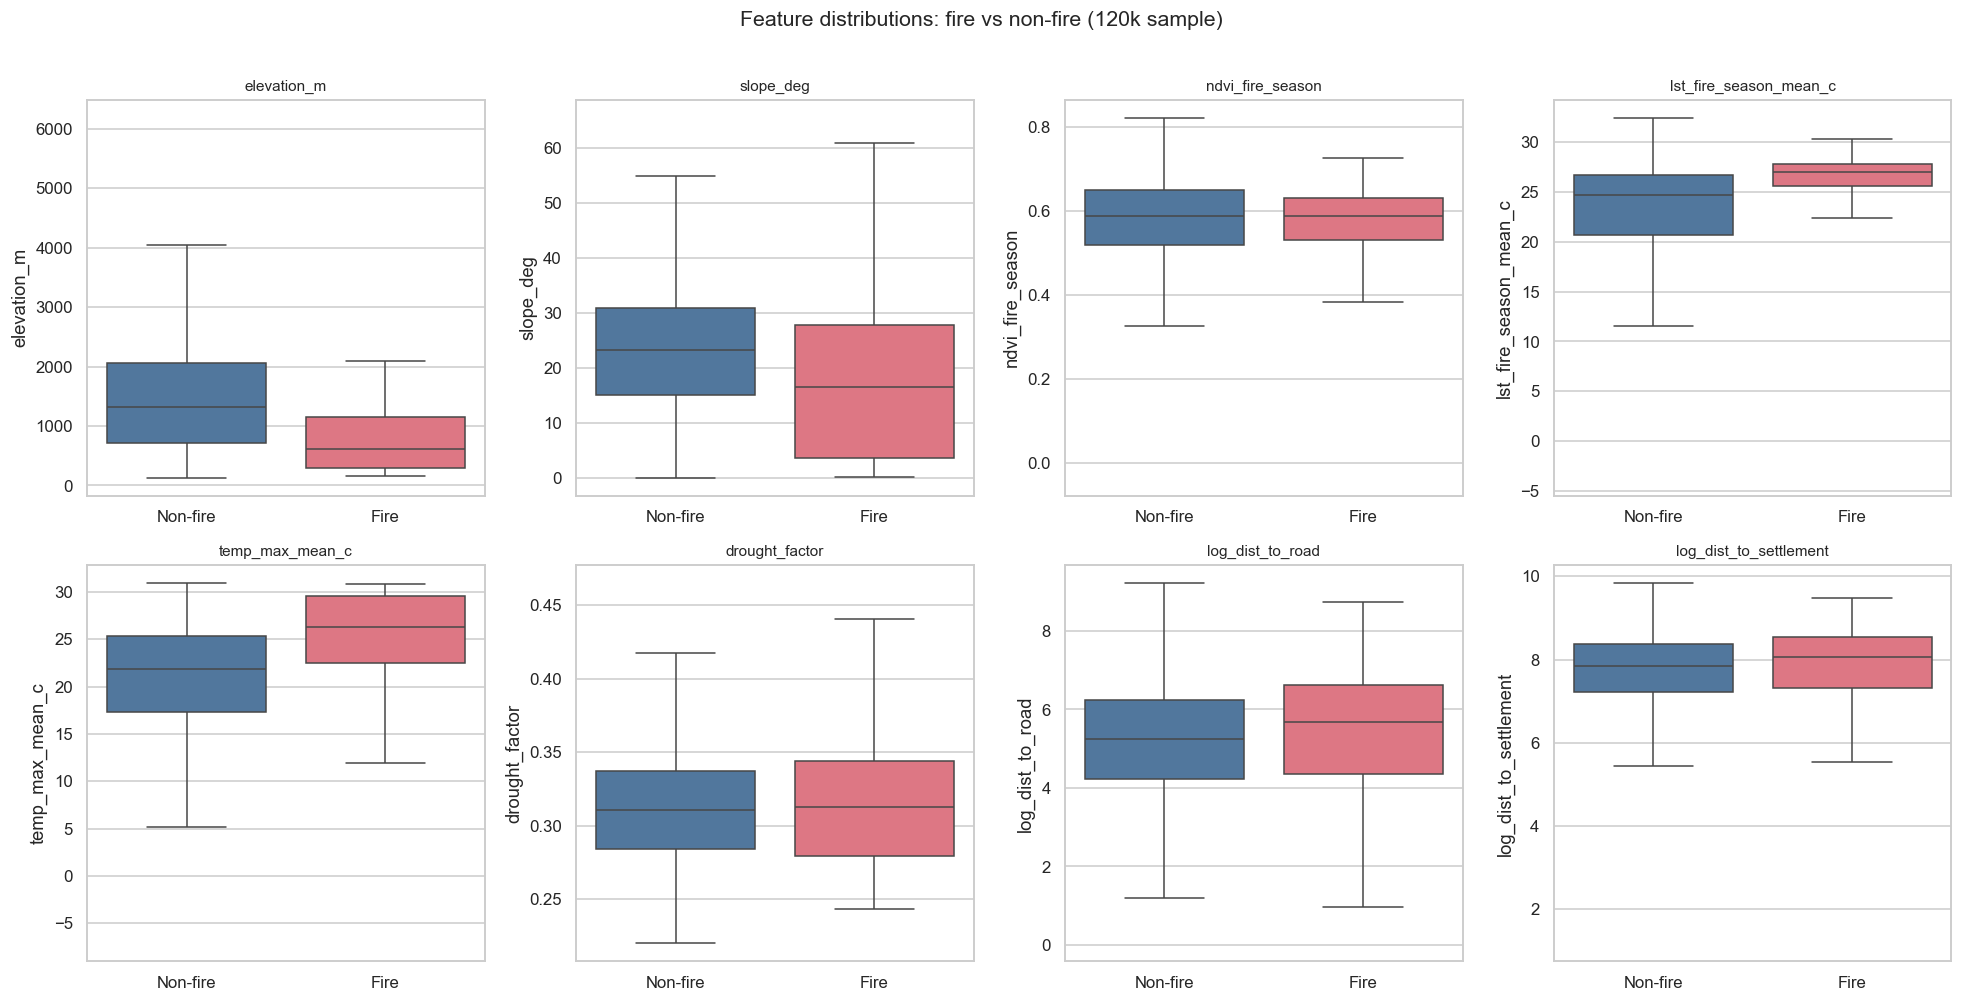

In [7]:
SEP = [
    "elevation_m",
    "slope_deg",
    "ndvi_fire_season",
    "lst_fire_season_mean_c",
    "temp_max_mean_c",
    "drought_factor",
    "log_dist_to_road",
    "log_dist_to_settlement"
    ]
samp = df.sample(min(120000, len(df)), random_state=42)
fig, axes = plt.subplots(2, 4, figsize=(18, 9)); axes = axes.ravel()
for ax, c in zip(axes, SEP):
    sns.boxplot(data=samp, x="fire_occurred", y=c, ax=ax, palette=["#4477AA","#EE6677"], fliersize=0)
    ax.set_xticklabels(["Non-fire","Fire"]); ax.set_xlabel(""); ax.set_title(c, fontsize=10)
fig.suptitle("Feature distributions: fire vs non-fire (120k sample)", y=1.01, fontsize=14)
plt.tight_layout()
plt.savefig(EDA/"boxplots.png", bbox_inches="tight")
plt.show()

**Analysis** <br>

These eight features individually show meaningful separation, confirming they're strong predictors. The overlapping distributions mean no single feature is decisive — an ensemble model is appropriate.

## Scatter plots (bivariate structure)

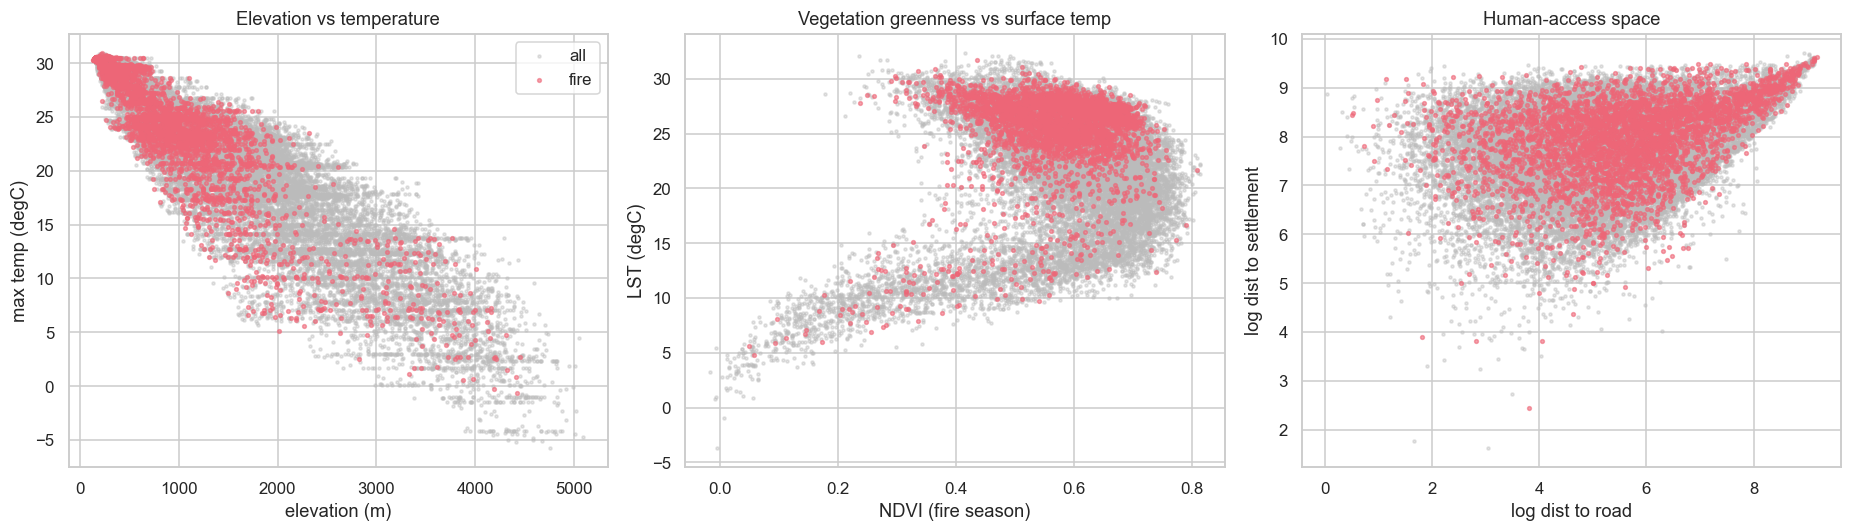

In [8]:
s = df.sample(min(25000, len(df)), random_state=42)
sf = df[df.fire_occurred==1].sample(min(4000, int(df.fire_occurred.sum())), random_state=42)

fig, ax = plt.subplots(1, 3, figsize=(17, 5))

ax[0].set_title("Elevation vs temperature")
ax[0].scatter(s.elevation_m, s.temp_max_mean_c, s=4, c="#BBBBBB", alpha=0.4, label="all")
ax[0].scatter(sf.elevation_m, sf.temp_max_mean_c, s=6, c="#EE6677", alpha=0.6, label="fire")
ax[0].set_xlabel("elevation (m)")
ax[0].set_ylabel("max temp (degC)")
ax[0].legend()

ax[1].set_title("Vegetation greenness vs surface temp")
ax[1].scatter(s.ndvi_fire_season, s.lst_fire_season_mean_c, s=4, c="#BBBBBB", alpha=0.4)
ax[1].scatter(sf.ndvi_fire_season, sf.lst_fire_season_mean_c, s=6, c="#EE6677", alpha=0.6)
ax[1].set_xlabel("NDVI (fire season)")
ax[1].set_ylabel("LST (degC)")

ax[2].set_title("Human-access space")
ax[2].scatter(s.log_dist_to_road, s.log_dist_to_settlement, s=4, c="#BBBBBB", alpha=0.4)
ax[2].scatter(sf.log_dist_to_road, sf.log_dist_to_settlement, s=6, c="#EE6677", alpha=0.6)
ax[2].set_xlabel("log dist to road")
ax[2].set_ylabel("log dist to settlement")
plt.tight_layout()
plt.savefig(EDA/"scatter.png", bbox_inches="tight")
plt.show()

**Analysis** <br>

The bivariate plots reveal interaction effects. A fire is most likely where multiple conditions align: warm, dry, accessible terrain.

## Fire rate vs elevation & distance-to-road


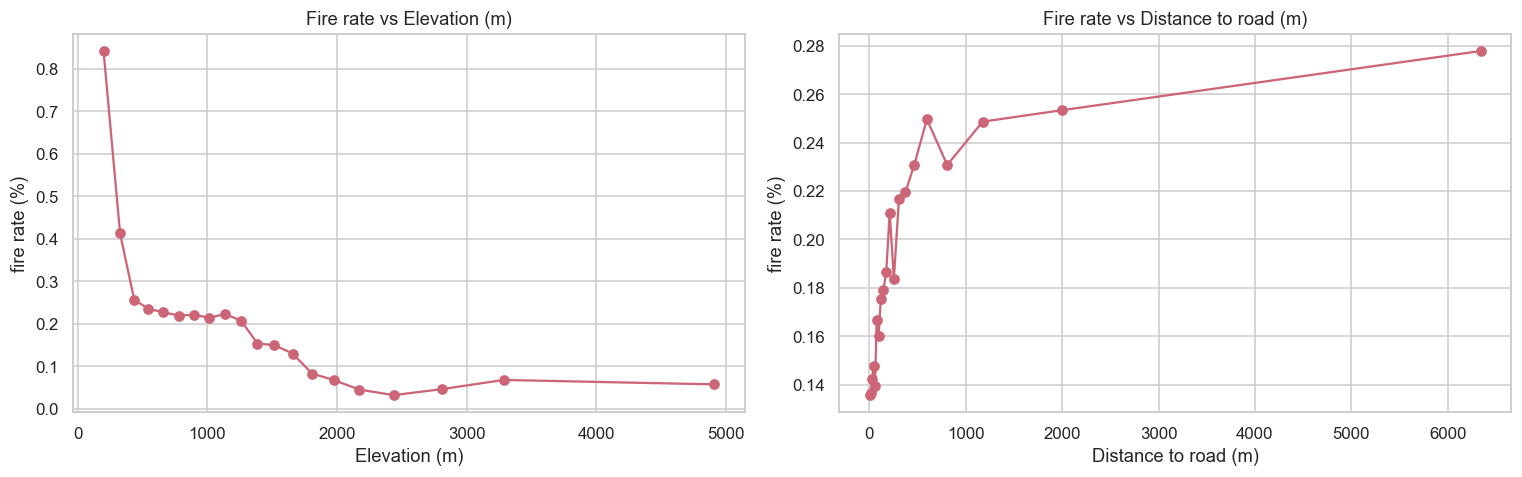

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
for axi, (c, lab) in zip(ax, [("elevation_m","Elevation (m)"),("dist_to_road_m","Distance to road (m)")]):
    b = pd.qcut(df[c], 20, duplicates="drop")
    g = df.groupby(b).fire_occurred.mean()*100
    centers = [iv.mid for iv in g.index]
    axi.plot(centers, g.values, marker="o", color="#CC6677")
    axi.set_xlabel(lab)
    axi.set_ylabel("fire rate (%)")
    axi.set_title(f"Fire rate vs {lab}")
plt.tight_layout()
plt.savefig(EDA/"firerate_bins.png")
plt.show()

**Analysis**

These nonlinear relationships justify using tree-based models (Random Forest, XGBoost, LightGBM) over linear classifiers.

## Summary statistics

In [10]:
desc = df[FEAT[:-1]].describe().T[["mean","std","min","25%","50%","75%","max"]].round(2)
print("saved figures to", EDA)
for f in sorted(p.name for p in EDA.glob("*.png")):
    print("  ", f)
desc

saved figures to /Users/sleepdeprived/Documents/Nayan/MTech_AI/DataAnalytics/forest-fire/outputs/figures/eda
   boxplots.png
   correlation.png
   firerate_bins.png
   histograms.png
   landcover.png
   missing.png
   rasters.png
   scatter.png
   target_overview.png


,mean,std,min,25%,50%,75%,max
elevation_m,1512.50,997.88,125.62,717.76,1323.61,2061.71,6270.97
slope_deg,22.91,11.34,0.00,15.00,23.35,30.97,70.64
aspect_sin,-0.02,0.70,-1.00,-0.71,-0.04,0.66,1.00
aspect_cos,-0.02,0.72,-1.00,-0.74,-0.05,0.70,1.00
tri,102.14,52.28,0.00,67.25,99.85,134.24,570.47
twi,1.06,0.89,-1.05,0.51,0.84,1.31,6.91
solar_radiation,0.92,0.30,-0.55,0.72,0.97,1.16,1.41
temp_max_mean_c,20.58,7.03,-7.13,17.20,21.83,25.43,30.96
wind_max_mean_kmh,0.92,0.41,0.17,0.67,0.89,1.07,2.43
precip_fire_season_mm,233.20,37.58,124.46,204.53,231.34,263.71,371.56
